# Choose seed points, assign demand, run GA and plot networks

In [17]:
import numpy as np
import matplotlib.pyplot as plt

## Seed points

Start with a rectangle shape for a city (we'll switch to a real city and street network later), then create a grid of seed points over that shape.

In [ ]:
import shapely
from shapely import Polygon, Point

In [19]:
coords = [(0., 0.), (0., 100.), (100., 100.), (100., 0.)]

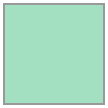

In [20]:
city = Polygon(coords)
city

### Hexagons

https://www.redblobgames.com/grids/hexagons/

In [33]:
# Code based on https://www.redblobgames.com/grids/hexagons/

def hex_corner(centre: shapely.Point, size: float, i: int) -> shapely.Point:
    """Produces the ith corner of a flat-top regular hexagon as a Shapely point.
    
    Args:
        centre: The centre of the hexagon.
        size: The distance from the hexagon's centre to one of its corners.
        i: Which corner (out of 6).
    
    Returns:
        A shapely.Point representing the ith corner of a hexagon.
    """
    angle_deg = 60 * i
    angle_rad = np.pi / 180 * angle_deg
    return Point(centre.x + size * np.cos(angle_rad),
                 centre.y + size * np.sin(angle_rad))

In [36]:
def create_hexagon(centre: shapely.Point, size: float) -> shapely.Polygon:
    """Creates a flat-top regular hexagon as a Shapely polygon.
    
    Args:
        centre: The centre of the hexagon.
        size: The distance from the hexagon's centre to one of its corners.
    
    Returns:
        A flat-top regular hexagon.
    """
    coords = []
    for i in range(1,7):
        coords.append(hex_corner(centre, size, i))
    return Polygon(coords)

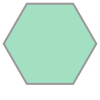

In [35]:
centre_ex = Point(50., 50.)
size_ex = 5
my_hex = create_hexagon(centre_ex, size_ex)
my_hex

In [ ]:
# Next step... create grid of hexagon vertices over the 'city' shape
# See https://www.redblobgames.com/grids/hexagons/ and https://www.redblobgames.com/grids/hexagons/implementation.html